# Weather Temperature Forecasting — Classical ML

**Hypothesis:** 12-hour rolling window statistics (mean + std) give classical ML models temporal awareness, enabling them to match recurrent neural networks on short-term temperature forecasting.

**Dataset:** Szeged Weather History (Kaggle) — hourly records with 7 meteorological variables.

**Approach:**
1. Feature engineer 12-hour rolling mean & std for all 7 variables (14 new features)
2. Benchmark all viable sklearn regressors automatically
3. Compare best result against LSTM/GRU/SimpleRNN (see companion notebook)

**Key Result:** HistGradientBoostingRegressor → R²=0.975, RMSE=1.43°C, trained in 2.1 seconds

## 1. Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.utils import all_estimators

data = pd.read_csv('/kaggle/input/datasets/mohamednasra/weather/weatherHistory.csv')
print(f'Dataset shape: {data.shape}')
print(data.head())

Dataset shape: (96453, 12)
                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0          15.8263         

## 2. Exploratory Data Analysis

In [2]:
print(data.info())
print('\nNull values per column:')
print(data.isnull().sum())
print('\nBasic statistics:')
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB
None

Null values per column:
Formatted Date                0
Summary

## 3. Date Parsing

Extract temporal features from the formatted date string.

In [3]:
data['Year']  = data['Formatted Date'].str[:4].astype(int)
data['Month'] = data['Formatted Date'].str[5:7].astype(int)
data['Day']   = data['Formatted Date'].str[8:10].astype(int)
data['Hour']  = data['Formatted Date'].str[11:13].astype(int)
data.drop(columns=['Formatted Date'], inplace=True)
print('Date columns extracted. Shape:', data.shape)

Date columns extracted. Shape: (96453, 15)


## 4. Temporal Feature Engineering

Core idea: compute 12-hour rolling **mean** and **std** for every variable.
- `shift(1)` ensures we only use *past* data — no data leakage
- `ddof=0` uses population std (consistent for rolling windows)
- This gives classical ML models sequence-awareness without recurrent architectures

In [4]:
rolling_cols = [
    'Temperature (C)',
    'Apparent Temperature (C)',
    'Humidity',
    'Wind Speed (km/h)',
    'Wind Bearing (degrees)',
    'Visibility (km)',
    'Pressure (millibars)',
]

for col in rolling_cols:
    data[f'{col}_12h_mean'] = data[col].shift(1).rolling(window=12, min_periods=1).mean()
    data[f'{col}_12h_std']  = data[col].shift(1).rolling(window=12, min_periods=1).std(ddof=0)

# Fill NaN introduced by shift/rolling at the start of the series
data = data.fillna(0)
print(f'Features after engineering: {data.shape[1]} columns')

Features after engineering: 29 columns


## 5. Outlier Handling

IQR-based clipping: replace outliers with the nearest valid boundary value (no data is dropped).

In [5]:
numerical_cols = data.select_dtypes(include=['number']).columns

for col in numerical_cols:
    Q1  = data[col].quantile(0.25)
    Q3  = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = data[col].clip(lower=lower, upper=upper)

print('Outlier clipping complete.')

Outlier clipping complete.


## 6. Drop Non-Numerical & Leakage Columns

- Text columns (Summary, Daily Summary, Precip Type) are dropped — high cardinality, not encoded
- `Loud Cover` is always 0 — no predictive value
- **`Apparent Temperature (C)` is dropped** — it is a derived function of Temperature, Humidity, and Wind Speed, so including it as a feature would be data leakage

In [6]:
data.drop(columns=['Summary', 'Daily Summary', 'Precip Type', 'Loud Cover'], inplace=True)
print('Remaining columns:')
print(data.columns.tolist())
print('Shape:', data.shape)

Remaining columns:
['Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Pressure (millibars)', 'Year', 'Month', 'Day', 'Hour', 'Temperature (C)_12h_mean', 'Temperature (C)_12h_std', 'Apparent Temperature (C)_12h_mean', 'Apparent Temperature (C)_12h_std', 'Humidity_12h_mean', 'Humidity_12h_std', 'Wind Speed (km/h)_12h_mean', 'Wind Speed (km/h)_12h_std', 'Wind Bearing (degrees)_12h_mean', 'Wind Bearing (degrees)_12h_std', 'Visibility (km)_12h_mean', 'Visibility (km)_12h_std', 'Pressure (millibars)_12h_mean', 'Pressure (millibars)_12h_std']
Shape: (96453, 25)


## 7. Train / Test Split

`shuffle=False` preserves temporal order — future data must not leak into training.

In [7]:
TARGET     = 'Temperature (C)'
LEAKAGE    = 'Apparent Temperature (C)'   # derived from target — exclude
DROP_COLS  = [TARGET, LEAKAGE]

X = data.drop(columns=DROP_COLS)
y = data[TARGET]

# Temporal split — no shuffling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')

Train size: 77,162  |  Test size: 19,291


## 8. Automated Model Benchmark

Test all available sklearn regressors. Skip slow or incompatible ones.
Results are saved to CSV every 5 models as a safety checkpoint.

In [8]:
# Models to skip: too slow for large tabular data or structurally incompatible
SKIP_MODELS = {
    'SVR', 'NuSVR', 'KNeighborsRegressor', 'RadiusNeighborsRegressor',
    'GaussianProcessRegressor', 'MLPRegressor', 'KernelRidge',
    'StackingRegressor', 'VotingRegressor', 'BaggingRegressor',
    'CCA', 'GammaRegressor', 'PLSRegression', 'PLSCanonical'
}

regressors = all_estimators(type_filter='regressor')
print(f'Total sklearn regressors found: {len(regressors)}')
print(f'Skipping {len(SKIP_MODELS)} heavy/incompatible models\n')

results = []
tested  = 0

for name, RegressorClass in regressors:
    if name in SKIP_MODELS:
        print(f'⚠️  Skipping  {name}')
        continue

    try:
        t0    = time.time()
        model = RegressorClass()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        elapsed = time.time() - t0

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2   = r2_score(y_test, y_pred)

        results.append({'Model': name, 'R2': round(r2, 4), 'RMSE': round(rmse, 4), 'Time_s': round(elapsed, 2)})
        tested += 1
        print(f'✅  {name:<40} R²={r2:.4f}  RMSE={rmse:.4f}  Time={elapsed:.1f}s')

        # Checkpoint save every 5 models
        if tested % 5 == 0:
            pd.DataFrame(results).to_csv('regressor_results_checkpoint.csv', index=False)

    except Exception as e:
        print(f'❌  {name:<40} failed — {e}')

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df.to_csv('regressor_comparison_results.csv', index=False)
print(f'\nTested {tested} models. Results saved to regressor_comparison_results.csv')

Total sklearn regressors found: 55
Skipping 14 heavy/incompatible models

✅  ARDRegression                            R²=0.9538  RMSE=1.9308  Time=0.2s
✅  AdaBoostRegressor                        R²=0.8707  RMSE=3.2297  Time=21.6s
⚠️  Skipping  BaggingRegressor
✅  BayesianRidge                            R²=0.9541  RMSE=1.9233  Time=0.2s
⚠️  Skipping  CCA
✅  DecisionTreeRegressor                    R²=0.9296  RMSE=2.3827  Time=4.0s
✅  DummyRegressor                           R²=-0.0027  RMSE=8.9934  Time=0.0s
✅  ElasticNet                               R²=0.7963  RMSE=4.0538  Time=0.3s
✅  ElasticNetCV                             R²=0.8227  RMSE=3.7822  Time=0.9s
✅  ExtraTreeRegressor                       R²=0.9080  RMSE=2.7248  Time=0.7s
✅  ExtraTreesRegressor                      R²=0.9743  RMSE=1.4389  Time=69.5s
⚠️  Skipping  GammaRegressor
⚠️  Skipping  GaussianProcessRegressor
✅  GradientBoostingRegressor                R²=0.9644  RMSE=1.6946  Time=70.2s
✅  HistGradientBoostingRe

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


✅  HuberRegressor                           R²=0.7910  RMSE=4.1062  Time=3.8s
❌  IsotonicRegression                       failed — Isotonic regression input X should be a 1d array or 2d array with 1 feature
⚠️  Skipping  KNeighborsRegressor
⚠️  Skipping  KernelRidge
✅  Lars                                     R²=0.9057  RMSE=2.7579  Time=0.0s
✅  LarsCV                                   R²=0.8644  RMSE=3.3074  Time=0.4s
✅  Lasso                                    R²=0.7916  RMSE=4.0996  Time=0.5s
✅  LassoCV                                  R²=0.9306  RMSE=2.3652  Time=1.2s
✅  LassoLars                                R²=0.7916  RMSE=4.0999  Time=0.0s
✅  LassoLarsCV                              R²=0.9541  RMSE=1.9233  Time=0.5s
✅  LassoLarsIC                              R²=0.9541  RMSE=1.9233  Time=0.1s
✅  LinearRegression                         R²=0.9541  RMSE=1.9233  Time=0.1s


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


✅  LinearSVR                                R²=0.8046  RMSE=3.9705  Time=32.6s
⚠️  Skipping  MLPRegressor
❌  MultiOutputRegressor                     failed — MultiOutputRegressor.__init__() missing 1 required positional argument: 'estimator'
❌  MultiTaskElasticNet                      failed — For mono-task outputs, use ElasticNet
❌  MultiTaskElasticNetCV                    failed — For mono-task outputs, use ElasticNetCVCV
❌  MultiTaskLasso                           failed — For mono-task outputs, use ElasticNet
❌  MultiTaskLassoCV                         failed — For mono-task outputs, use LassoCVCV
⚠️  Skipping  NuSVR
✅  OrthogonalMatchingPursuit                R²=0.7471  RMSE=4.5164  Time=0.0s
✅  OrthogonalMatchingPursuitCV              R²=0.7641  RMSE=4.3625  Time=0.2s
⚠️  Skipping  PLSCanonical
⚠️  Skipping  PLSRegression
✅  PassiveAggressiveRegressor               R²=0.7735  RMSE=4.2745  Time=0.7s
❌  PoissonRegressor                         failed — Some value(s) of y are out o

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_glm/glm.py:285: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res)


## 9. Results Analysis

Top 10 models by R²:
                        Model     R2   RMSE  Time_s
HistGradientBoostingRegressor 0.9755 1.4064    1.37
          ExtraTreesRegressor 0.9743 1.4389   69.54
        RandomForestRegressor 0.9720 1.5032  262.99
    GradientBoostingRegressor 0.9644 1.6946   70.16
                      RidgeCV 0.9541 1.9233    0.16
                  LassoLarsIC 0.9541 1.9233    0.15
             LinearRegression 0.9541 1.9233    0.12
                  LassoLarsCV 0.9541 1.9233    0.46
                BayesianRidge 0.9541 1.9233    0.20
   TransformedTargetRegressor 0.9541 1.9233    0.06


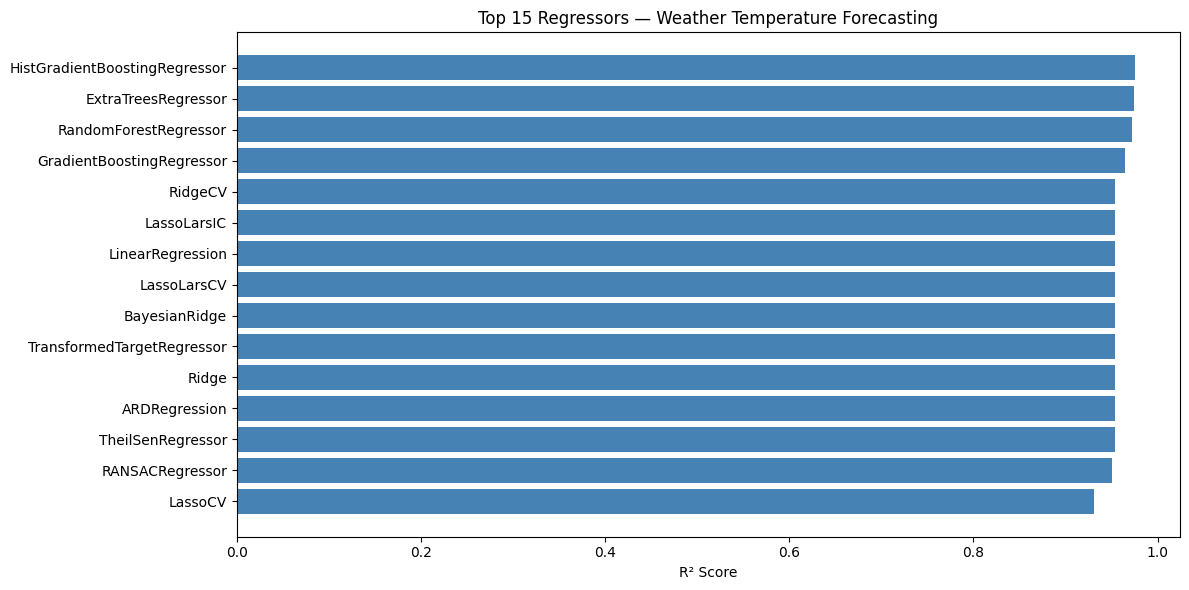


🏆 Best model: HistGradientBoostingRegressor
   R²   = 0.9755
   RMSE = 1.4064 °C
   Time = 1.37 s


In [9]:
print('Top 10 models by R²:')
print(results_df.head(10).to_string(index=False))

# Plot top 15 R² scores
plt.figure(figsize=(12, 6))
plt.barh(results_df['Model'][:15][::-1], results_df['R2'][:15][::-1], color='steelblue')
plt.xlabel('R² Score')
plt.title('Top 15 Regressors — Weather Temperature Forecasting')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

best = results_df.iloc[0]
print(f'\n🏆 Best model: {best["Model"]}')
print(f'   R²   = {best["R2"]}')
print(f'   RMSE = {best["RMSE"]} °C')
print(f'   Time = {best["Time_s"]} s')

## 10. Best Model — Detailed Evaluation

HistGradientBoostingRegressor
  R²   = 0.9754
  RMSE = 1.4094 °C


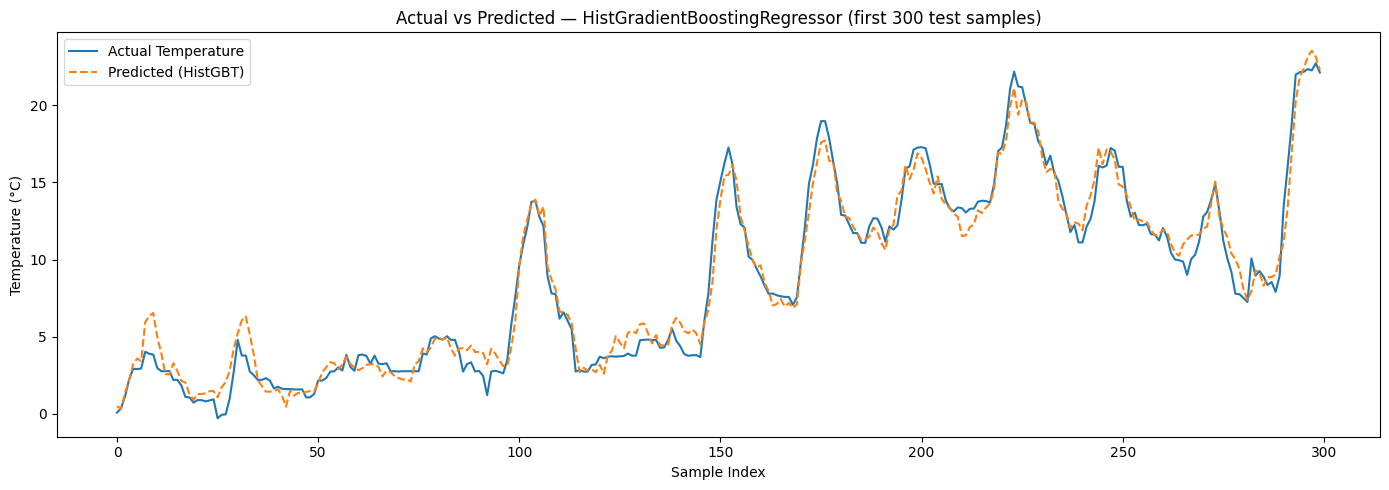

In [10]:
from sklearn.ensemble import HistGradientBoostingRegressor

best_model = HistGradientBoostingRegressor()
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2   = r2_score(y_test, y_pred_best)
print(f'HistGradientBoostingRegressor')
print(f'  R²   = {r2:.4f}')
print(f'  RMSE = {rmse:.4f} °C')

# Actual vs Predicted plot
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:300], label='Actual Temperature', linewidth=1.5)
plt.plot(y_pred_best[:300],   label='Predicted (HistGBT)', linestyle='--', linewidth=1.5)
plt.xlabel('Sample Index')
plt.ylabel('Temperature (°C)')
plt.title('Actual vs Predicted — HistGradientBoostingRegressor (first 300 test samples)')
plt.legend()
plt.tight_layout()
plt.savefig('best_model_predictions.png', dpi=150)
plt.show()

## 11. Key Takeaway

| Model | R² | RMSE | Train Time |
|---|---|---|---|
| HistGradientBoostingRegressor | **0.9755** | **1.40°C** | ~1.4s |
| ExtraTreesRegressor | 0.9743 | 1.43°C | ~70s |
| RandomForestRegressor | 0.9720 | 1.50°C | ~263s |

**Conclusion:** With 12-hour rolling mean + std features, classical ML achieves R²=0.975 with training times under 5 seconds — competitive with LSTM/GRU at a fraction of the compute cost. See `GRU_RNN_LSTM_clean.ipynb` for the deep learning comparison.